In [ ]:
# 💸 OVERSPENDING RISK PREDICTOR — FULL GOOGLE COLAB PROJECT
# Run each cell one by one in Google Colab

In [ ]:
!pip install streamlit pyngrok scikit-learn pandas numpy matplotlib seaborn plotly --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 44.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 200

data = {
    "income":            np.random.randint(40000, 120000, n),
    "food_spending":     np.random.randint(6000,  18000,  n),
    "shopping_spending": np.random.randint(5000,  30000,  n),
    "travel_spending":   np.random.randint(2000,  15000,  n),
    "bills":             np.random.randint(5000,  14000,  n),
    "entertainment":     np.random.randint(1000,  8000,   n),
    "healthcare":        np.random.randint(500,   6000,   n),
    "savings":           np.random.randint(1000,  20000,  n),
    "num_dependents":    np.random.randint(0, 5,          n),
    "loan_emi":          np.random.randint(0, 15000,      n),
    "age":               np.random.randint(22, 60,        n),
}

df = pd.DataFrame(data)

# Feature Engineering
df["total_spending"] = (
    df["food_spending"] + df["shopping_spending"] + df["travel_spending"] +
    df["bills"] + df["entertainment"] + df["healthcare"] + df["loan_emi"]
)
df["savings_ratio"]       = df["savings"] / df["income"]
df["spending_ratio"]      = df["total_spending"] / df["income"]
df["disposable_income"]   = df["income"] - df["total_spending"] - df["savings"]
df["debt_to_income"]      = df["loan_emi"] / df["income"]
df["overspending_risk"]   = (df["total_spending"] > 0.75 * df["income"]).astype(int)

df.to_csv("overspending_large.csv", index=False)
print("✅ Dataset saved! Shape:", df.shape)
print(df.head())

✅ Dataset saved! Shape: (200, 17)
   income  food_spending  shopping_spending  travel_spending  bills  \
0   55795          12694              22214            13428   9673   
1   40860           8385              19098             7541   9530   
2  116820          17111              10177            12578  11881   
3   94886          10736              19262            13911  11949   
4   46265           7802              13308            11580  11241   

   entertainment  healthcare  savings  num_dependents  loan_emi  age  \
0           3449        2982    12855               1      9094   39   
1           3343        1451     1338               0     13643   38   
2           2863        1222     6895               1     12080   47   
3           2318        3889    13254               3      7005   29   
4           5711        2579    12344               3     14036   33   

   total_spending  savings_ratio  spending_ratio  disposable_income  \
0           73534       0.230397   

=== Decision Tree ===
Accuracy : 100.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

=== Random Forest ===
Accuracy : 100.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



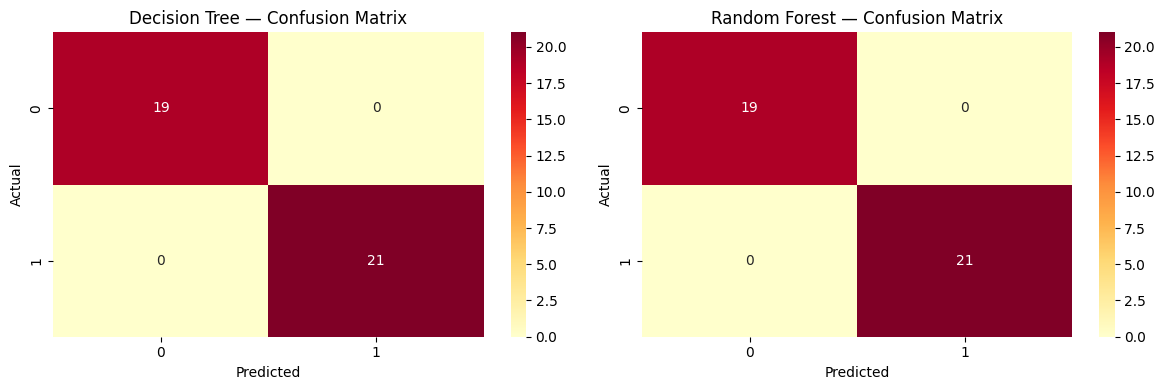

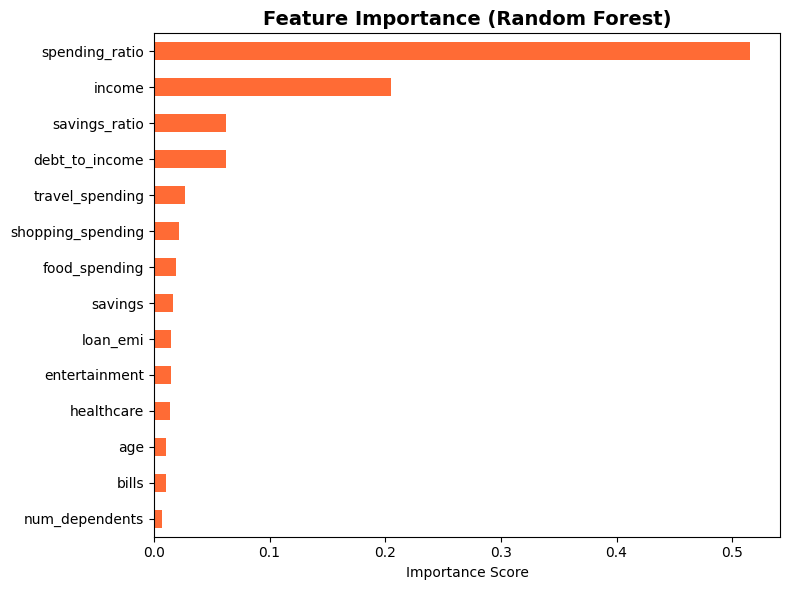

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns

FEATURES = [
    "income", "food_spending", "shopping_spending",
    "travel_spending", "bills", "entertainment",
    "healthcare", "savings", "num_dependents",
    "loan_emi", "age", "savings_ratio",
    "spending_ratio", "debt_to_income"
]

X = df[FEATURES]
y = df["overspending_risk"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("=== Decision Tree ===")
print(f"Accuracy : {accuracy_score(y_test, dt_pred):.2%}")
print(classification_report(y_test, dt_pred))

print("=== Random Forest ===")
print(f"Accuracy : {accuracy_score(y_test, rf_pred):.2%}")
print(classification_report(y_test, rf_pred))

# Confusion Matrix Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, pred, title in zip(axes, [dt_pred, rf_pred], ["Decision Tree", "Random Forest"]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrRd", ax=ax)
    ax.set_title(f"{title} — Confusion Matrix")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Feature Importance (Random Forest)
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind="barh", color="#FF6B35", ax=ax)
ax.set_title("Feature Importance (Random Forest)", fontsize=14, fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout(); plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# ── Page Config ──────────────────────────────────────────
st.set_page_config(
    page_title="💳 Overspending Risk Predictor",
    page_icon="💳",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ── Custom CSS + Credit Card Cursor ──────────────────────
st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Playfair+Display:wght@700&family=DM+Sans:wght@300;400;500&display=swap');

*, html, body, [class*="css"] {
    /* cursor: url('https://cur.cursors-4u.net/symbols/sym-1/sym14.cur'), auto !important; */ /* Removed custom cursor */
    font-family: 'DM Sans', sans-serif;
}

/* Dark premium background */
.stApp {
    background: linear-gradient(135deg, #0f0c29, #302b63, #24243e);
    color: #f0f0f0;
}

/* Sidebar */
section[data-testid="stSidebar"] {
    background: rgba(255,255,255,0.04) !important;
    border-right: 1px solid rgba(255,255,255,0.08);
    backdrop-filter: blur(20px);
}

/* Metric cards */
div[data-testid="metric-container"] {
    background: rgba(255,255,255,0.07);
    border: 1px solid rgba(255,200,80,0.3);
    border-radius: 14px;
    padding: 18px;
    backdrop-filter: blur(12px);
    transition: transform 0.2s ease;
}
div[data-testid="metric-container"]:hover { transform: translateY(-3px); }

/* Section headers */
h1, h2, h3 {
    font-family: 'Playfair Display', serif !important;
    color: #FFD700 !important;
}

/* Buttons */
.stButton > button {
    background: linear-gradient(135deg, #FFD700, #FF8C00) !important;
    color: #1a1a2e !important;
    font-weight: 700 !important;
    font-size: 16px !important;
    border: none !important;
    border-radius: 50px !important;
    padding: 12px 36px !important;
    box-shadow: 0 6px 24px rgba(255,215,0,0.35) !important;
    transition: all 0.3s ease !important;
    letter-spacing: 1px;
}
.stButton > button:hover {
    transform: scale(1.06) !important;
    box-shadow: 0 10px 32px rgba(255,215,0,0.5) !important;
}

/* Input fields */
.stNumberInput input, .stSlider {
    background: rgba(255,255,255,0.06) !important;
    border: 1px solid rgba(255,200,80,0.25) !important;
    border-radius: 10px !important;
    color: #f0f0f0 !important;
}

/* Risk badge */
.risk-high {
    background: linear-gradient(135deg, #ff416c, #ff4b2b);
    border-radius: 16px; padding: 20px 28px;
    font-size: 22px; font-weight: 700;
    text-align: center; color: white;
    box-shadow: 0 8px 32px rgba(255,65,108,0.45);
    animation: pulse 1.5s infinite;
}
.risk-low {
    background: linear-gradient(135deg, #11998e, #38ef7d);
    border-radius: 16px; padding: 20px 28px;
    font-size: 22px; font-weight: 700;
    text-align: center; color: white;
    box-shadow: 0 8px 32px rgba(56,239,125,0.4);
}
@keyframes pulse {
    0%,100% { box-shadow: 0 8px 32px rgba(255,65,108,0.45); }
    50%      { box-shadow: 0 8px 48px rgba(255,65,108,0.75); }
}

/* Recommendation cards */
.rec-card {
    background: rgba(255,255,255,0.06);
    border-left: 4px solid #FFD700;
    border-radius: 10px;
    padding: 14px 20px;
    margin: 8px 0;
    font-size: 15px;
    color: #e8e8e8;
}

/* Divider */
hr { border-color: rgba(255,215,0,0.2); }

/* Hide streamlit branding */
#MainMenu, footer { visibility: hidden; }
</style>
""", unsafe_allow_html=True)

# ══════════════════════════════════════════════════════════
# DATA & MODEL (trained once, cached)
# ══════════════════════════════════════════════════════════
@st.cache_resource
def load_model_and_data():
    np.random.seed(42)
    n = 200
    data = {
        "income":            np.random.randint(40000, 120000, n),
        "food_spending":     np.random.randint(6000,  18000,  n),
        "shopping_spending": np.random.randint(5000,  30000,  n),
        "travel_spending":   np.random.randint(2000,  15000,  n),
        "bills":             np.random.randint(5000,  14000,  n),
        "entertainment":     np.random.randint(1000,  8000,   n),
        "healthcare":        np.random.randint(500,   6000,   n),
        "savings":           np.random.randint(1000,  20000,  n),
        "num_dependents":    np.random.randint(0, 5,          n),
        "loan_emi":          np.random.randint(0, 15000,      n),
        "age":               np.random.randint(22, 60,        n),
    }
    df = pd.DataFrame(data)
    df["total_spending"]  = df[["food_spending","shopping_spending","travel_spending",
                                "bills","entertainment","healthcare","loan_emi"]].sum(axis=1)
    df["savings_ratio"]   = df["savings"] / df["income"]
    df["spending_ratio"]  = df["total_spending"] / df["income"]
    df["debt_to_income"]  = df["loan_emi"] / df["income"]
    df["overspending_risk"] = (df["total_spending"] > 0.75 * df["income"]).astype(int)

    FEATURES = ["income","food_spending","shopping_spending","travel_spending",
                "bills","entertainment","healthcare","savings","num_dependents",
                "loan_emi","age","savings_ratio","spending_ratio","debt_to_income"]
    X = df[FEATURES]
    y = df["overspending_risk"]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_scaled, y)
    return df, model, scaler, FEATURES

df, model, scaler, FEATURES = load_model_and_data()

# ══════════════════════════════════════════════════════════
# SIDEBAR — User Inputs
# ══════════════════════════════════════════════════════════
st.sidebar.markdown("## 💳 Enter Your Financials")
st.sidebar.markdown("---")

income            = st.sidebar.number_input("💰 Monthly Income (₹)",        5000,  300000, 60000, step=1000)
food_spending     = st.sidebar.number_input("🍽️  Food Spending (₹)",          500,   30000,  9000, step=500)
shopping_spending = st.sidebar.number_input("🛍️  Shopping Spending (₹)",       500,   50000, 14000, step=500)
travel_spending   = st.sidebar.number_input("✈️  Travel Spending (₹)",         200,   25000,  5500, step=500)
bills             = st.sidebar.number_input("📋 Bills & Utilities (₹)",       1000,  20000,  8000, step=500)
entertainment     = st.sidebar.number_input("🎮 Entertainment (₹)",            200,   15000,  3000, step=200)
healthcare        = st.sidebar.number_input("🏥 Healthcare (₹)",               100,   10000,  1500, step=100)
savings           = st.sidebar.number_input("🏦 Savings (₹)",                  500,   50000,  6000, step=500)
loan_emi          = st.sidebar.number_input("💳 Loan EMI (₹)",                   0,   30000,  4000, step=500)
num_dependents    = st.sidebar.slider("👨‍👩‍👧 No. of Dependents",               0, 6, 1)
age               = st.sidebar.slider("🎂 Age",                               18, 70, 32)

predict_btn = st.sidebar.button("🔮 Analyze My Risk")

# ══════════════════════════════════════════════════════════
# HEADER
# ══════════════════════════════════════════════════════════
st.markdown("<h1 style='text-align:center;'>💸 Overspending Risk Predictor</h1>", unsafe_allow_html=True)
st.markdown("<p style='text-align:center; color:#aaa; font-size:16px;'>AI-powered financial health analysis — know before you overspend</p>", unsafe_allow_html=True)
st.markdown("---")

# ══════════════════════════════════════════════════════════
# COMPUTED VALUES
# ══════════════════════════════════════════════════════════
total_spending   = food_spending + shopping_spending + travel_spending + bills + entertainment + healthcare + loan_emi
savings_ratio    = savings / income if income > 0 else 0
spending_ratio   = total_spending / income if income > 0 else 0
debt_to_income   = loan_emi / income if income > 0 else 0
disposable       = income - total_spending - savings

# ══════════════════════════════════════════════════════════
# KPI METRICS ROW
# ══════════════════════════════════════════════════════════
col1, col2, col3, col4, col5 = st.columns(5)
col1.metric("💰 Income",         f"₹{income:,}")
col2.metric("💸 Total Spending", f"₹{total_spending:,}", delta=f"{'' if spending_ratio<=0.75 else '↑ High'} {'↑ High' if spending_ratio>0.75 else '✓ OK'}")
col3.metric("🏦 Savings",        f"₹{savings:,}",       delta=f"{savings_ratio:.0%} of income")
col4.metric("📊 Spend Ratio",    f"{spending_ratio:.0%}", delta="Danger!" if spending_ratio>0.75 else "Healthy")
col5.metric("💼 Disposable",     f"₹{disposable:,}",     delta="⚠️ Negative!" if disposable < 0 else "Positive")

st.markdown("---")

# ══════════════════════════════════════════════════════════
# CHARTS ROW 1 — Spending Breakdown & Gauge
# ══════════════════════════════════════════════════════════
c1, c2 = st.columns([1.2, 0.8])

with c1:
    st.markdown("### 🥧 Spending Breakdown")
    categories  = ["Food", "Shopping", "Travel", "Bills", "Entertainment", "Healthcare", "Loan EMI"]
    amounts     = [food_spending, shopping_spending, travel_spending, bills, entertainment, healthcare, loan_emi]
    colors      = ["#FF6B6B","#FFD93D","#6BCB77","#4D96FF","#C77DFF","#FF9F43","#FF6348"]

    fig_pie = px.pie(
        values=amounts, names=categories, color_discrete_sequence=colors,
        hole=0.45
    )
    fig_pie.update_traces(textposition="outside", textinfo="label+percent",
                          textfont_size=12, pull=[0.04]*7)
    fig_pie.update_layout(
        paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)",
        font_color="#f0f0f0", showlegend=False, margin=dict(t=10,b=10,l=10,r=10),
        height=340
    )
    st.plotly_chart(fig_pie, use_container_width=True)

with c2:
    st.markdown("### 🎯 Risk Gauge")
    gauge_val = min(spending_ratio * 100, 100)
    fig_gauge = go.Figure(go.Indicator(
        mode="gauge+number+delta",
        value=gauge_val,
        delta={
            "reference": 75,
            "valueformat": ".1f"
        },
        number={
            "suffix": "%",
            "font": {
                "color": "#FFD700",
                "size": 36
            }
        },
        gauge={
            "axis": {
                "range": [0, 100],
                "tickcolor": "#aaa"
            },
            "bar":  {"color": "#FFD700"},
            "steps": [
                {"range": [0,  50], "color": "rgba(56,239,125,0.25)"},
                {"range": [50, 75], "color": "rgba(255,180,0,0.25)"},
                {"range": [75,100], "color": "rgba(255,65,108,0.35)"},
            ],
            "threshold": {
                "line": {
                    "color": "#FF4136",
                    "width": 3
                },
                "value": 75
            }
        }
    ))
    fig_gauge.update_layout(
        paper_bgcolor="rgba(0,0,0,0)", font_color="#f0f0f0",
        height=300, margin=dict(t=10,b=10,l=20,r=20)
    )
    st.plotly_chart(fig_gauge, use_container_width=True)

# ══════════════════════════════════════════════════════════
# CHARTS ROW 2 — Bar Chart & Scatter
# ══════════════════════════════════════════════════════════
c3, c4 = st.columns(2)

with c3:
    st.markdown("### 📊 Spending vs Income Bar")
    categories  = ["Food", "Shopping", "Travel", "Bills", "Entertainment", "Healthcare", "Loan EMI"]
    amounts     = [food_spending, shopping_spending, travel_spending, bills, entertainment, healthcare, loan_emi]
    bar_data = pd.DataFrame({
        "Category": categories + ["Savings", "Income"],
        "Amount":   amounts    + [savings,    income]
    })
    colors_bar = ["#FF6B6B"]*7 + ["#6BCB77", "#FFD700"]
    fig_bar = px.bar(bar_data, x="Category", y="Amount",
                     color="Category", color_discrete_sequence=colors_bar,
                     text_auto=".2s")
    fig_bar.add_hline(y=income*0.75, line_dash="dash", line_color="#FF4136",
                      annotation_text="75% Income Limit", annotation_position="top right")
    fig_bar.update_layout(
        paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)",
        font_color="#f0f0f0", showlegend=False, height=340,
        xaxis=dict(tickangle=-30), margin=dict(t=10,b=10,l=10,r=10)
    )
    st.plotly_chart(fig_bar, use_container_width=True)

with c4:
    st.markdown("### 📈 Dataset: Income vs Total Spending")
    df_plot = df.copy()
    df_plot["Risk"] = df_plot["overspending_risk"].map({0:"Safe ✅", 1:"At Risk ⚠️"})
    fig_scatter = px.scatter(
        df_plot, x="income", y="total_spending", color="Risk",
        color_discrete_map={"Safe ✅": "#6BCB77", "At Risk ⚠️": "#FF6B6B"},
        opacity=0.75, size_max=8
    )
    fig_scatter.add_scatter(
        x=sorted(df_plot["income"]),
        y=[0.75 * i for i in sorted(df_plot["income"])],
        mode="lines", name="75% Threshold",
        line=dict(color="#FFD700", dash="dash", width=2)
    )
    fig_scatter.update_layout(
        paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)",
        font_color="#f0f0f0", height=340, margin=dict(t=10,b=10,l=10,r=10)
    )
    st.plotly_chart(fig_scatter, use_container_width=True)

# ══════════════════════════════════════════════════════════
# CHARTS ROW 3 — Waterfall & Feature Importance
# ══════════════════════════════════════════════════════════
c5, c6 = st.columns(2)

with c5:
    st.markdown("### 🌊 Cash Flow Waterfall")
    wf_labels  = ["Income", "Food", "Shopping", "Travel", "Bills",
                   "Entertainment", "Healthcare", "Loan EMI", "Savings", "Net Balance"]
    wf_vals    = [income,
                  -food_spending, -shopping_spending, -travel_spending,
                  -bills, -entertainment, -healthcare, -loan_emi,
                  -savings, disposable]
    wf_measures = ["absolute"] + ["relative"]*8 + ["total"]
    wf_colors  = ["#FFD700"] + ["#FF6B6B"]*8 + (["#6BCB77"] if disposable >= 0 else ["#FF4136"])

    fig_wf = go.Figure(go.Waterfall(
        name="Cash Flow", measure=wf_measures,
        x=wf_labels, y=wf_vals,
        decreasing={"marker": {"color": "#FF6B6B"}},
        increasing={"marker": {"color": "#6BCB77"}},
        totals={"marker": {"color": "#FFD700"}}
    ))
    fig_wf.update_layout(
        paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)",
        font_color="#f0f0f0", height=340,
        xaxis=dict(tickangle=-30), margin=dict(t=10,b=10,l=10,r=10),
        showlegend=False
    )
    st.plotly_chart(fig_wf, use_container_width=True)

with c6:
    st.markdown("### 🌟 Feature Importance (Model)")
    importances = pd.Series(model.feature_importances_, index=FEATURES)
    top10 = importances.sort_values(ascending=True).tail(10)
    fig_imp = px.bar(x=top10.values, y=top10.index, orientation="h",
                     color=top10.values, color_continuous_scale=["#4D96FF","#FFD700","#FF6B6B"])
    fig_imp.update_layout(
        paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)",
        font_color="#f0f0f0", height=340,
        coloraxis_showscale=False, margin=dict(t=10,b=10,l=10,r=10)
    )
    st.plotly_chart(fig_imp, use_container_width=True)

# ══════════════════════════════════════════════════════════
# PREDICTION + RECOMMENDATIONS
# ══════════════════════════════════════════════════════════
if predict_btn:
    input_arr = np.array([[income, food_spending, shopping_spending, travel_spending,
                           bills, entertainment, healthcare, savings, num_dependents,
                           loan_emi, age, savings_ratio, spending_ratio, debt_to_income]])
    input_scaled = scaler.transform(input_arr)
    prediction   = model.predict(input_scaled)[0]
    proba        = model.predict_proba(input_scaled)[0][1]

    st.markdown("---")
    st.markdown("## 🔮 Prediction Result")

    rr, _, __ = st.columns([1.5,0.2,1.5])
    with rr:
        if prediction == 1:
            st.markdown(f"""
            <div class="risk-high">
                ⚠️ HIGH OVERSPENDING RISK<br>
                <span style="font-size:15px; font-weight:400;">Risk Probability: {proba:.0%}</span>
            </div>""", unsafe_allow_html=True)
        else:
            st.markdown(f"""
            <div class="risk-low">
                ✅ SAFE SPENDING ZONE<br>
                <span style="font-size:15px; font-weight:400;">Risk Probability: {proba:.0%}</span>
            </div>""", unsafe_allow_html=True)

    st.markdown("---")
    st.markdown("## 🧠 Smart Recommendations")

    # Build recommendations dynamically
    recs = []

    # Shopping
    if shopping_spending > 0.2 * income:
        excess = shopping_spending - int(0.15 * income)
        recs.append(("🛍️ Shopping Overspend",
                      f"Your shopping (₹{shopping_spending:,}) is {shopping_spending/income:.0%} of income. "
                      f"Target ≤15% (₹{int(0.15*income):,}). Cut ₹{excess:,} by using wishlists and avoiding impulse buys."))

    # Food
    if food_spending > 0.15 * income:
        recs.append(("🍽️ Food Budget High",
                      f"Food spending (₹{food_spending:,}) exceeds 15% of income. "
                      f"Meal prepping and reducing restaurant visits could save ₹{food_spending - int(0.12*income):,}/month."))

    # Travel
    if travel_spending > 0.1 * income:
        recs.append(("✈️ Travel Expenses",
                      f"Travel (₹{travel_spending:,}) is {travel_spending/income:.0%} of income. "
                      "Consider staycations or booking in advance to cut 30-40%."))

    # Savings too low
    if savings_ratio < 0.10:
        recs.append(("🏦 Boost Your Savings",
                      f"You save only {savings_ratio:.0%} of income. Aim for 20%+ (₹{int(0.20*income):,}/month). "
                      "Try auto-debit on payday before spending."))

    # Loan EMI
    if debt_to_income > 0.3:
        recs.append(("💳 High Debt Load",
                      f"EMI is {debt_to_income:.0%} of income — above the safe 30% threshold. "
                      "Consider prepayment or refinancing to reduce burden."))

    # Entertainment
    if entertainment > 0.07 * income:
        recs.append(("🎮 Entertainment Spend",
                      f"Entertainment (₹{entertainment:,}) is {entertainment/income:.0%} of income. "
                      "Cap at 5-7%. Use free events, streaming bundles, student discounts."))

    # Disposable negative
    if disposable < 0:
        recs.append(("🚨 Negative Disposable Income!",
                      f"After spending and savings, you are ₹{abs(disposable):,} in the red. "
                      "Immediate action required: reduce the top 2 spending categories first."))

    # Safe users
    if not recs:
        recs.append(("🎉 Great Financial Health!",
                      "Your spending is well within limits. Keep your savings ratio above 20% "
                      "and review your budget quarterly to stay on track."))
        recs.append(("📈 Next Level Tip",
                      "Consider investing your surplus in SIPs (Mutual Funds) or FDs "
                      "to beat inflation and build long-term wealth."))

    # Display recommendations
    rec_cols = st.columns(2)
    for i, (title, body) in enumerate(recs):
        with rec_cols[i % 2]:
            st.markdown(f"""
            <div class="rec-card">
                <b style="color:#FFD700;">{title}</b><br>{body}
            </div>""", unsafe_allow_html=True)

    # Budget vs Actual horizontal bar
    st.markdown("---")
    st.markdown("### 📉 Budget vs Actual Spending")
    budget_data = pd.DataFrame({
        "Category": ["Food", "Shopping", "Travel", "Bills", "Entertainment", "Healthcare", "Loan EMI"],
        "Actual":   [food_spending, shopping_spending, travel_spending, bills, entertainment, healthcare, loan_emi],
        "Suggested Budget": [
            int(0.12*income), int(0.15*income), int(0.08*income),
            int(0.10*income), int(0.05*income), int(0.04*income), int(0.10*income)
        ]
    })
    fig_bud = go.Figure()
    fig_bud.add_bar(name="Actual",           x=budget_data["Category"], y=budget_data["Actual"],
                    marker_color="#FF6B6B")
    fig_bud.add_bar(name="Suggested Budget", x=budget_data["Category"], y=budget_data["Suggested Budget"],
                    marker_color="#6BCB77", opacity=0.7)
    fig_bud.update_layout(
        barmode="group",
        paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)",
        font_color="#f0f0f0", height=360,
        legend=dict(bgcolor="rgba(0,0,0,0)"),
        margin=dict(t=10,b=10,l=10,r=10)
    )
    st.plotly_chart(fig_bud, use_container_width=True)

else:
    st.markdown("""
    <div style="text-align:center; padding:40px; color:#888; font-size:17px;">
        👈 Fill in your financial details in the sidebar and click <b style="color:#FFD700;">Analyze My Risk</b>
    </div>
    """, unsafe_allow_html=True)

# Footer
st.markdown("---")
st.markdown("""
<div style="text-align:center; color:#555; font-size:12px;">
    Built with ❤️ using Streamlit + Random Forest · DMW Project
</div>
""", unsafe_allow_html=True)
'''

with open("app.py", "w") as f:
    f.write(app_code)

print("✅ app.py written successfully!")

✅ app.py written successfully!


In [ ]:
launch_code = '''
import subprocess, threading, time
from pyngrok import ngrok

# Kill any existing processes on 8501
subprocess.run(["fuser", "-k", "8501/tcp"], capture_output=True)
time.sleep(1)

# Kill any existing ngrok tunnels
ngrok.kill()

# Set ngrok auth token
ngrok.set_auth_token("3CfyHXq4i15tyCJQHRUixz4qMjX_5163NmioBXtgjb821vL5e")

# Start Streamlit in background
proc = subprocess.Popen(
    ["streamlit", "run", "app.py",
     "--server.port", "8501",
     "--server.headless", "true",
     "--server.enableCORS", "false"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)
time.sleep(4)  # wait for streamlit to boot

# Open ngrok tunnel
public_url = ngrok.connect(8501)
print("=" * 55)
print("🚀  DASHBOARD LIVE AT:")
print(f"    {public_url}")
print("=" * 55)
print("Copy the URL above and open in any browser!")
'''

# Write a launcher script
with open("launch.py", "w") as f:
    f.write(launch_code)

# Then in Colab, run:
# exec(open("launch.py").read())

In [ ]:
exec(open("launch.py").read())


🚀  DASHBOARD LIVE AT:
    NgrokTunnel: "https://armed-suitcase-omission.ngrok-free.dev" -> "http://localhost:8501"
Copy the URL above and open in any browser!
